### **Business Problem:**

Yulu is India’s leading micro-mobility service provider, which offers unique vehicles for the daily commute. Starting off as a mission to eliminate traffic congestion in India, Yulu provides the safest commute solution through a user-friendly mobile app to enable shared, solo and sustainable commuting.

Yulu zones are located at all the appropriate locations (including metro stations, bus stands, office spaces, residential areas, corporate offices, etc) to make those first and last miles smooth, affordable, and convenient!

Yulu has recently suffered considerable dips in its revenues. They have contracted a consulting company to understand the factors on which the demand for these shared electric cycles depends. Specifically, they want to understand the factors affecting the demand for these shared electric cycles in the Indian market.

The company wants to know:
1. Which variables are significant in predicting the demand for shared electric cycles in the Indian market?
2. How well those variables describe the electric cycle demands


In [87]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from statsmodels.stats import weightstats as stests
from scipy.stats import ttest_1samp, ttest_ind, ttest_rel, chisquare, chi2, chi2_contingency
from scipy.stats import f_oneway #1-way Anova # Numeric Vs categorical for many categories
from scipy.stats import kruskal
from statsmodels.graphics.gofplots import qqplot #scipy --> probplot
from scipy.stats import shapiro,skew, kurtosis
from scipy.stats import levene
import warnings

In [88]:
df_yulu = pd.read_csv('C:\\Users\\njain121\\Desktop\\Scalar\\CaseStudy\\Yulu\\bike_sharing.csv')
df_yulu.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


### Column Profiling: ###

- datetime: datetime
- season: season (1: spring, 2: summer, 3: fall, 4: winter)
- holiday: whether day is a holiday or not (extracted from http://dchr.dc.gov/page/holiday-schedule)
- workingday: if day is neither weekend nor holiday is 1, otherwise is 0.
- weather:
    1: Clear, Few clouds, partly cloudy, partly cloudy
    2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
    3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
    4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog
- temp: temperature in Celsius
- atemp: feeling temperature in Celsius
- humidity: humidity
- windspeed: wind speed
- casual: count of casual users
- registered: count of registered users
- count: count of total rental bikes including both casual and registered

In [89]:
df_yulu.shape

(10886, 12)

In [90]:
df_yulu.info()  ## details of the dataframe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [91]:
df_yulu.describe(include='all')

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
unique,10886,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2012-12-19 23:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,NaN,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,NaN,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,NaN,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,NaN,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,NaN,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000


In [92]:
print(df_yulu.isna().any().any())##Check for the missing values
print()
df_yulu.isna().sum()

False



datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64

In [93]:
## Unique Attributes
df_yulu.nunique().sort_values(ascending=False)

datetime      10886
count           822
registered      731
casual          309
humidity         89
atemp            60
temp             49
windspeed        28
season            4
weather           4
workingday        2
holiday           2
dtype: int64

In [94]:
## Identify if there is any duplicate row in the dataframe
duplicate_rows = df_yulu[df_yulu.duplicated()]
print("Duplicate rows identified:")
print(duplicate_rows)

Duplicate rows identified:
Empty DataFrame
Columns: [datetime, season, holiday, workingday, weather, temp, atemp, humidity, windspeed, casual, registered, count]
Index: []


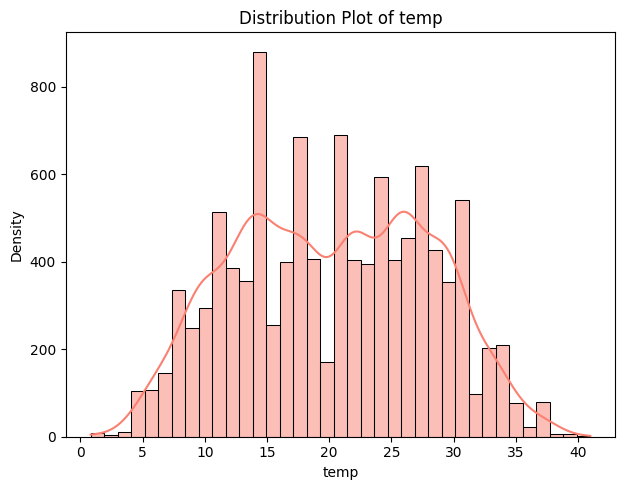

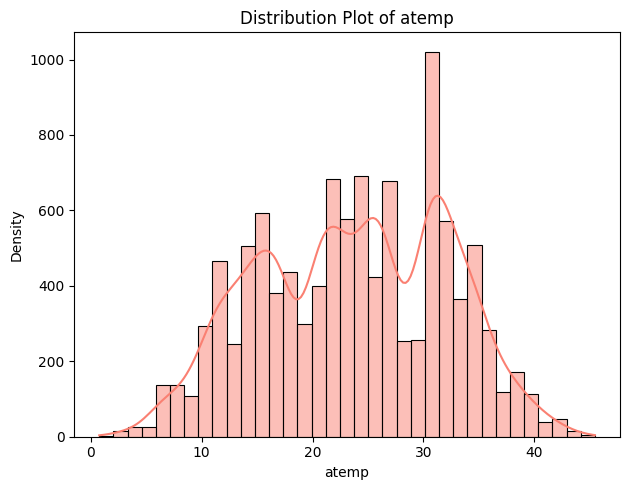

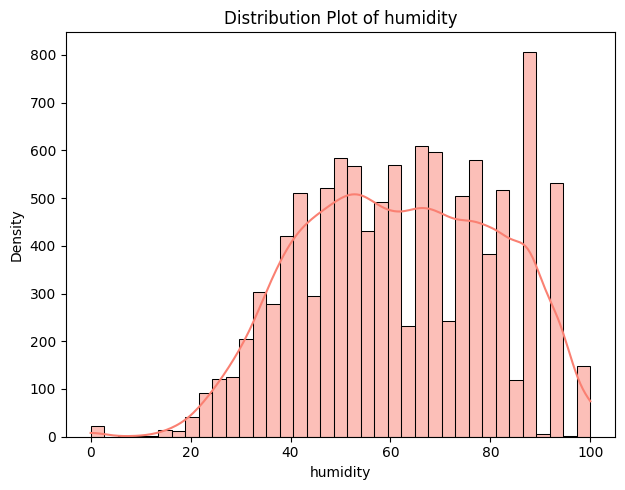

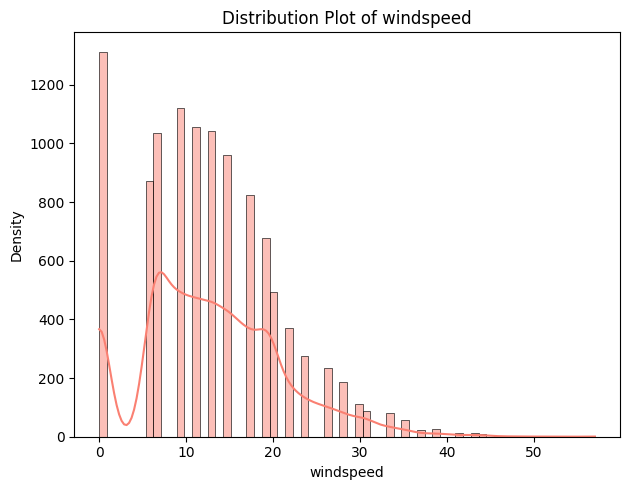

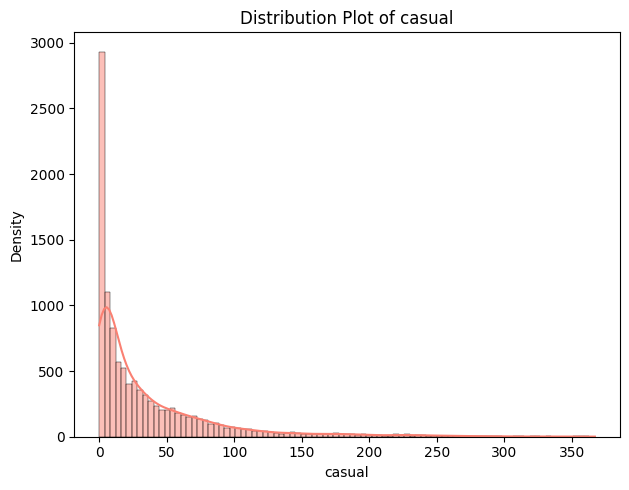

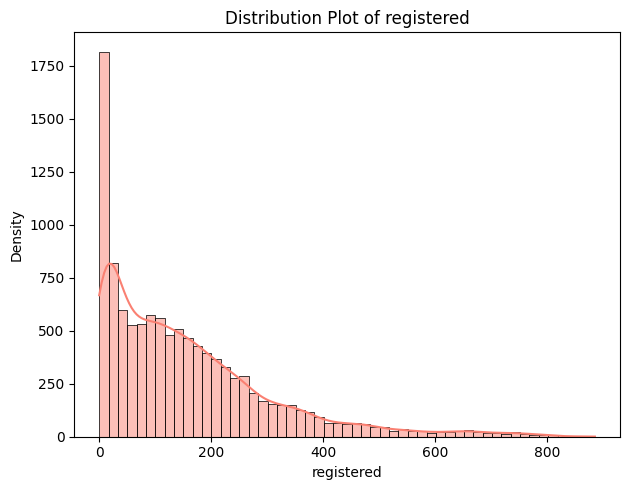

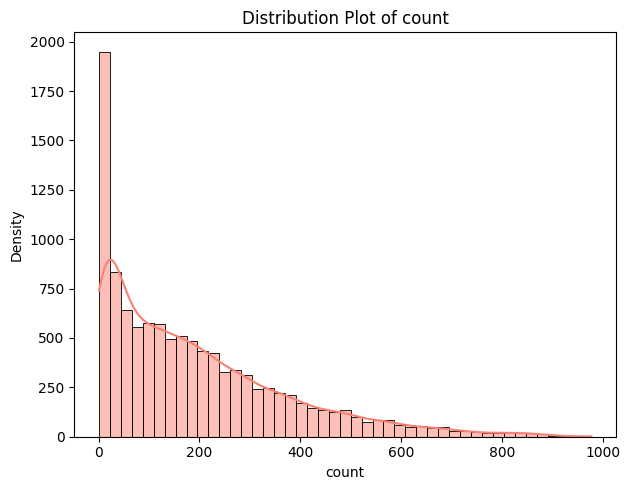

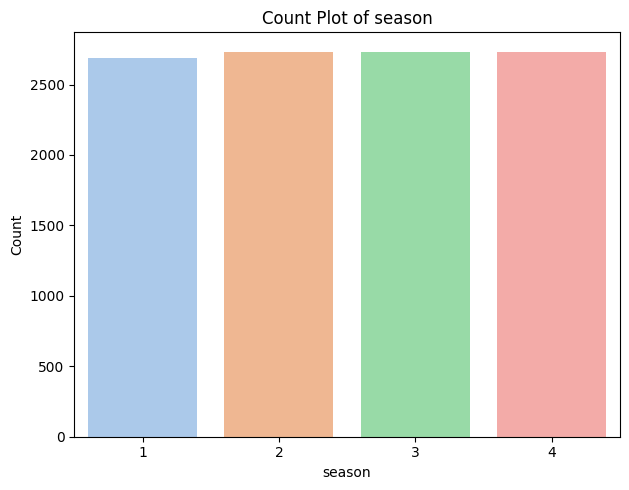

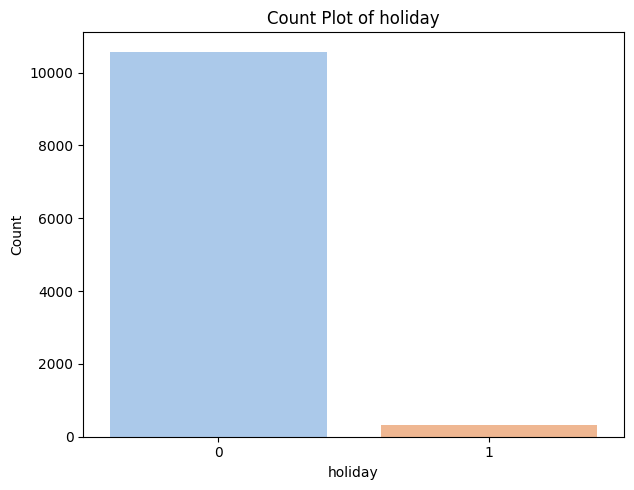

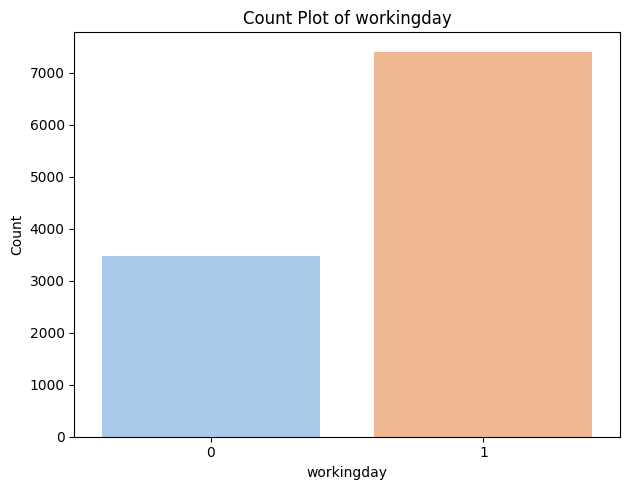

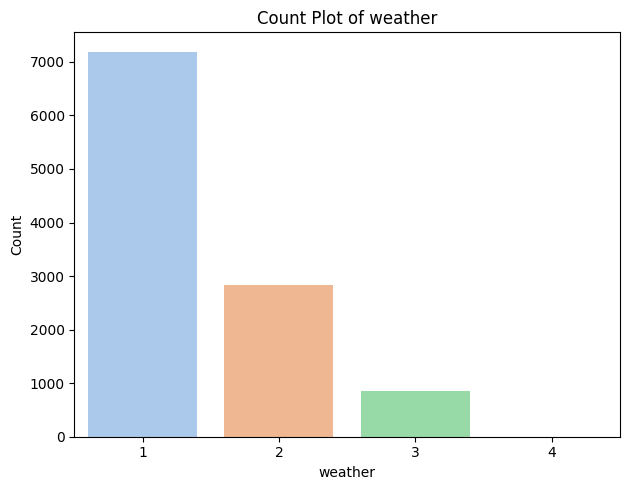

In [95]:
if df_yulu.columns[0] == '':
    df_yulu = df_yulu.drop(columns=df_yulu.columns[0])

# Identify numerical and categorical columns
numerical_cols = ['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']
categorical_cols = ['season', 'holiday', 'workingday', 'weather']

# Plot histograms and distribution plots for numerical features
for col in numerical_cols:
    
    plt.figure(figsize=(12, 5))        
    plt.subplot(1, 2, 1)
    sns.histplot(df_yulu[col], kde=True, color='salmon')
    plt.title(f'Distribution Plot of {col}')
    plt.xlabel(col)
    plt.ylabel('Density')
    
    plt.tight_layout()
    plt.show()

# Plot count plots and pie charts for categorical features
for col in categorical_cols:
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    sns.countplot(x=col, data=df_yulu, palette='pastel')
    plt.title(f'Count Plot of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    
    plt.tight_layout()
    plt.show()


# Key insights#
## Numerical columns ##
### 1. temp (temperature in Celsius): ###
    - temperatures are spread roughly between 0°C and 35°C, with most values concentrated in the 10–25°C range.
    - There are few or no extreme outliers, as the distribution tapers off smoothly on both ends.
### 2. atemp (feeling temperature in Celsius): ###
    - The distribution is slightly right-skewed, similar to actual temperature (temp).
    - Most values fall between 15°C and 35°C, indicating that users typically ride in comfortable weather.
    - The highest density is around 25°C, suggesting this is the most preferred or common feels-like temperature.
    - Very few values are below 10°C or above 40°C, showing limited usage in extreme conditions.

### 3. humidity: ###
    - The distribution is right-skewed, with a peak in the moderate humidity range (40–70%).
    - Most values fall between 40% and 70%, indicating that bike rides are common in moderately humid conditions.
    - There is a notable spike at 100%, which could indicate:
    - Data recording anomalies or rounding.
    - Frequent rides during very humid conditions (e.g., early mornings or rainy days).
    - Very few rides occur at humidity levels below 20%.
    
### 4. windspeed: ###
    - The highest density of bike rides occurs at very low wind speeds (0–5 units), indicating that users prefer calm conditions.
    - The distribution is right-skewed, with frequency decreasing as windspeed increases.
    - Most rides happen when windspeed is below 20 units, suggesting that moderate wind is acceptable for riders.
    - Very few rides occur at wind speeds above 30 units, showing that strong winds likely discourage bike usage.

### 5. casual (count of casual users): ###
    - The distribution is heavily right-skewed, indicating that most casual user counts are low.
    - The highest frequency is near 0–50 users, suggesting that casual usage is typically light.

### 6. registered (count of registered users): ###
    - The distribution is right-skewed, meaning most values are concentrated at the lower end, with fewer high-usage instances.
    - The highest density is observed between 0 and 200 registered users, indicating that most hourly records have relatively modest registered user counts.
    - There are occasional high spikes (up to 800+), suggesting that while rare, some hours experience very high registered user activity—likely during peak commuting times.
    - Registered users form the bulk of total usage, but their activity is still highly variable, possibly influenced by time of day, weekday vs. weekend, and weather.

## Categorical columns ##
- Bike usage is strongly influenced by weather, with clear conditions being the most favorable. As weather worsens, ride frequency drops sharply.
- There is a clear preference for bike usage on working days, likely due to commuting patterns. This trend highlights the importance of bike-sharing systems as a daily transport option for work-related travel.
- Unlike weather or working day, season does not appear to strongly influence the number of bike rides. This could indicate that users are well-adapted to seasonal changes, or that the bike-sharing system is effectively used throughout the year.
- Bike-sharing is used far more frequently on non-holidays, likely due to routine commuting. Holidays see a sharp decline in usage, possibly because people stay home or use other modes of transport for leisure.

## Check for Outliers and clip if neccessary ##

temp: 0 outliers
25%:  13.94 ; 75%:  26.24 ; IQR:  12.299999999999999 ; Lower whisker:  -4.51 ; Upper whisker:  44.69


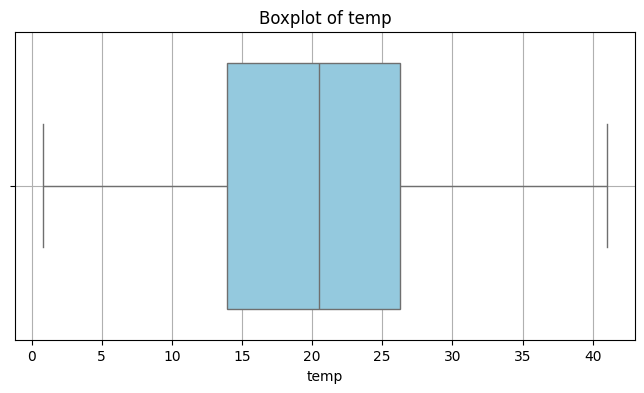

atemp: 0 outliers
25%:  16.665 ; 75%:  31.06 ; IQR:  14.395 ; Lower whisker:  -4.927500000000002 ; Upper whisker:  52.6525


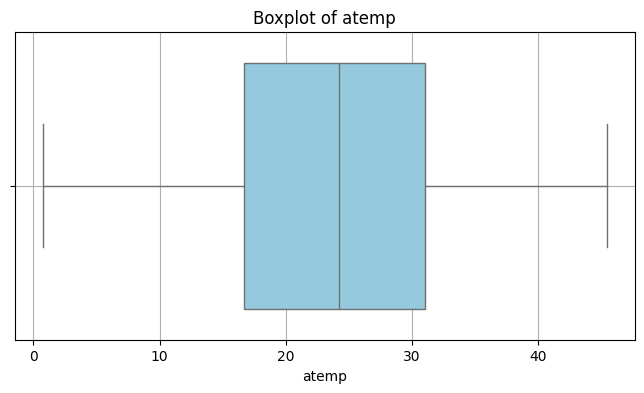

humidity: 22 outliers
25%:  47.0 ; 75%:  77.0 ; IQR:  30.0 ; Lower whisker:  2.0 ; Upper whisker:  122.0


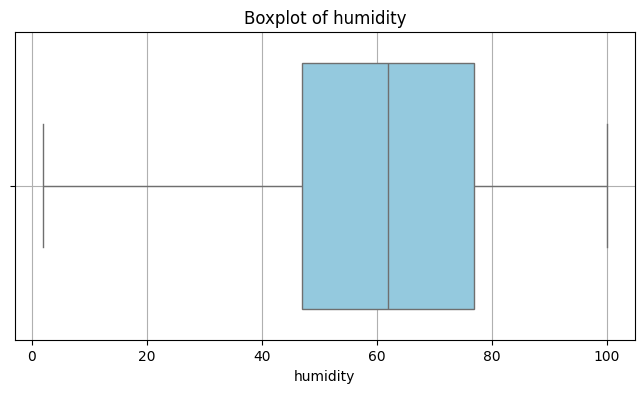

windspeed: 227 outliers
25%:  7.0015 ; 75%:  16.9979 ; IQR:  9.996400000000001 ; Lower whisker:  -7.993100000000002 ; Upper whisker:  31.992500000000003


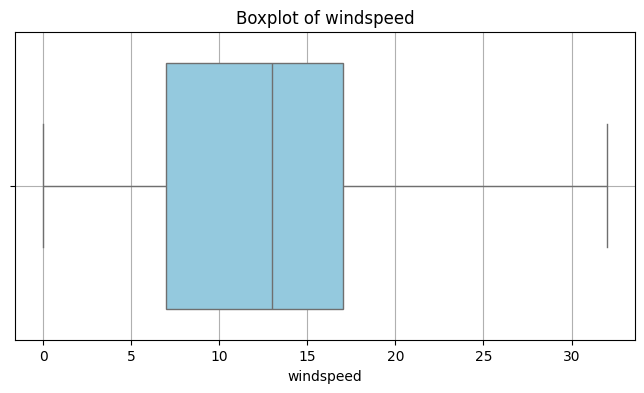

casual: 749 outliers
25%:  4.0 ; 75%:  49.0 ; IQR:  45.0 ; Lower whisker:  -63.5 ; Upper whisker:  116.5


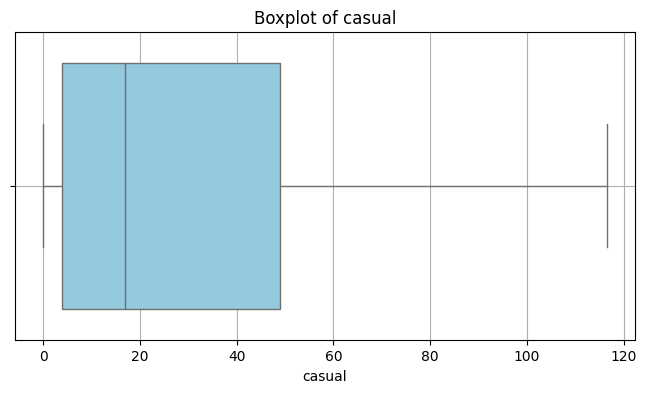

registered: 423 outliers
25%:  36.0 ; 75%:  222.0 ; IQR:  186.0 ; Lower whisker:  -243.0 ; Upper whisker:  501.0


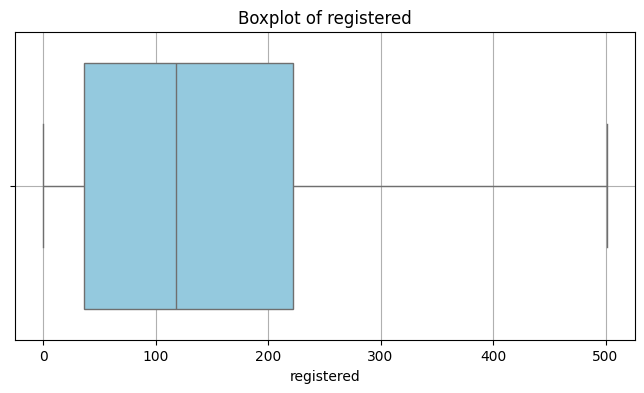

count: 300 outliers
25%:  42.0 ; 75%:  284.0 ; IQR:  242.0 ; Lower whisker:  -321.0 ; Upper whisker:  647.0


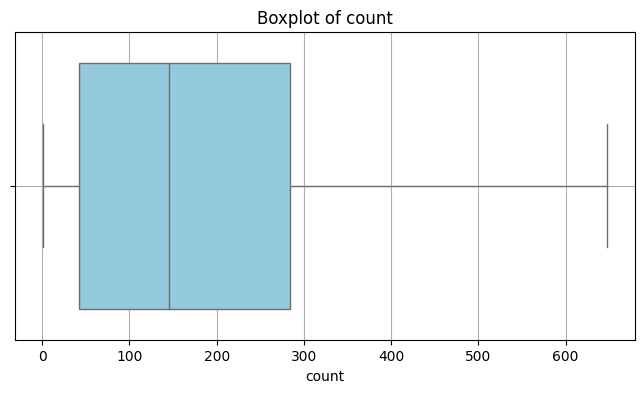

In [96]:
# List of numerical columns to check for outliers
numerical_cols = ['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']

# Create boxplots and identify outliers using IQR
for col in numerical_cols:
    Q1 = df_yulu[col].quantile(0.25)
    Q3 = df_yulu[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Print number of outliers
    outliers = df_yulu[(df_yulu[col] < lower_bound) | (df_yulu[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers")
    print('25%: ', Q1,'; 75%: ',  Q3,'; IQR: ', IQR, '; Lower whisker: ',  lower_bound, '; Upper whisker: ',upper_bound)

    # Clip outliers
    df_yulu[col] = df_yulu[col].clip(lower=lower_bound, upper=upper_bound)

    # Plot boxplot
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df_yulu[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.grid(True)
    plt.show()


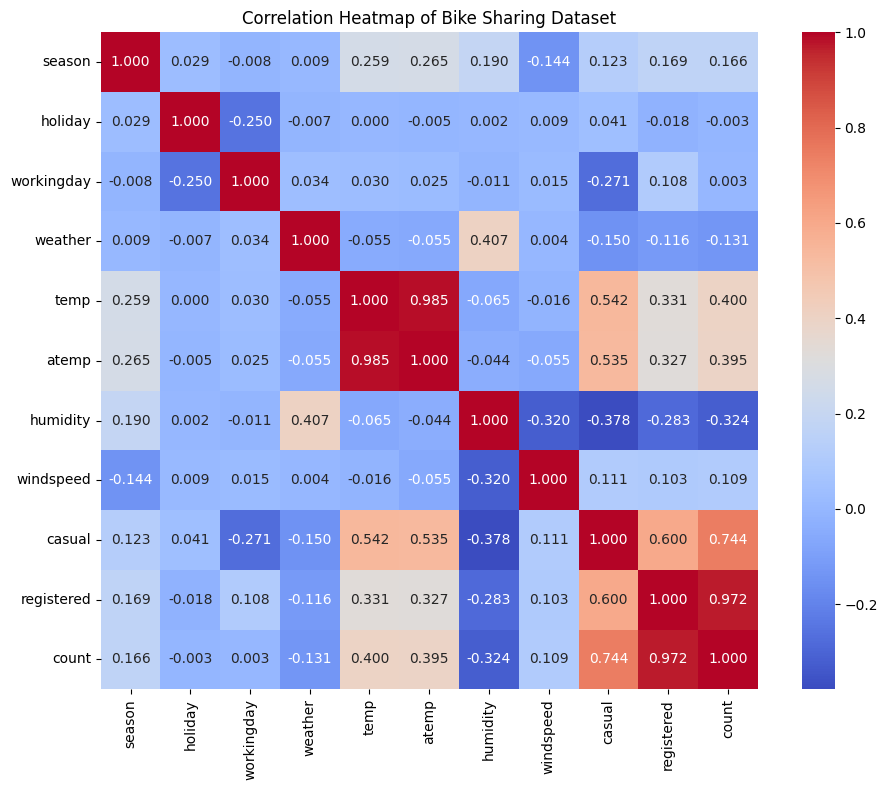

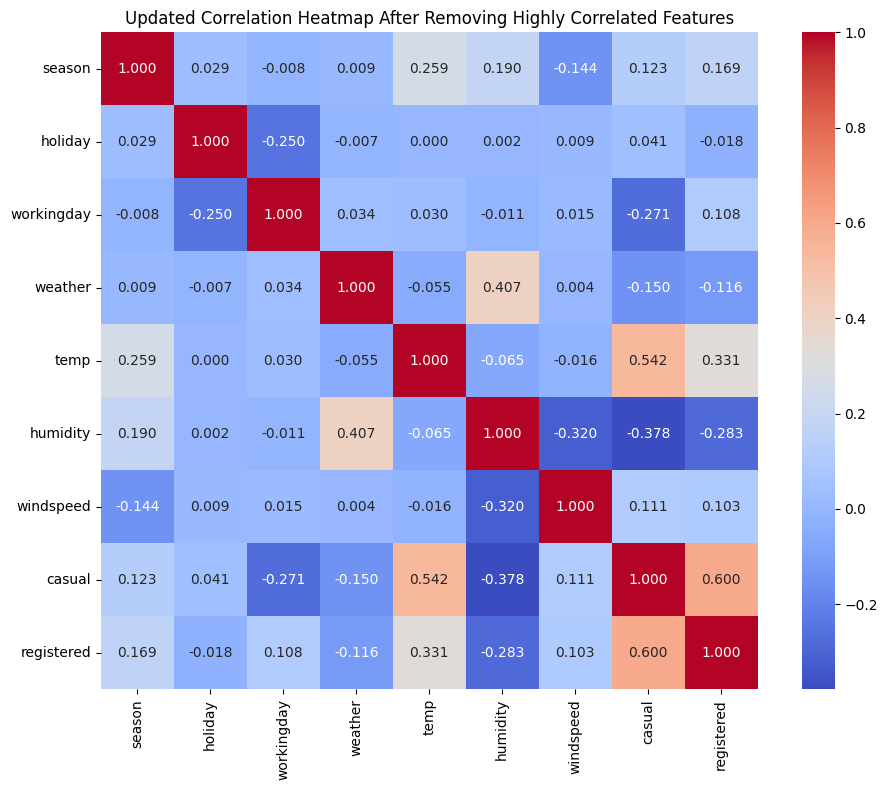

Correlation heatmaps and cleaned dataset have been generated.


In [97]:
# Drop non-numeric columns like 'datetime'
df = df_yulu.drop(columns=['datetime'])

# Compute the correlation matrix
correlation_matrix = df.corr()

# Plot the correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".3f", square=True)
plt.title("Correlation Heatmap of Bike Sharing Dataset")
plt.tight_layout()
plt.show()

# Identify highly correlated features (correlation > 0.85)
upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)
high_correlation = [column for column in upper_triangle.columns if any(upper_triangle[column].abs() > 0.85)]

# Drop highly correlated features
df_cleaned = df.drop(columns=high_correlation)

# Compute and plot the updated correlation heatmap
updated_correlation_matrix = df_cleaned.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(updated_correlation_matrix, annot=True, cmap='coolwarm', fmt=".3f", square=True)
plt.title("Updated Correlation Heatmap After Removing Highly Correlated Features")
plt.tight_layout()
plt.show()

print("Correlation heatmaps and cleaned dataset have been generated.")



## Key Insights ##
### Highly Correlated Features Removed ###
To avoid multicollinearity, the following features were removed due to high correlation (correlation > 0.85):
- atemp (feels-like temperature, highly correlated with temp)
- count (total count, highly correlated with registered and casual)

### Top Positive Correlations with count ###
These variables show the strongest positive relationships with the total bike rental count:
- registered: 0.97 — Strongest predictor of total count.
- casual: 0.74 — Also a strong contributor to total count.
- temp: 0.40 — Warmer temperatures are associated with more rentals.

### Negative Correlations with count ###
These variables are negatively associated with bike rentals:
- humidity: -0.32 — Higher humidity tends to reduce bike usage.
- weather: -0.13 — Worse weather conditions (e.g., rain, snow) reduce rentals.
- holiday: -0.003 — Slightly fewer rentals on holidays, though the effect is minimal.

## Check if there any significant difference between the no. of bike rides on Weekdays and Weekends? ##
- Null Hypothesis (H₀): There is no significant difference in the number of bike rides between weekdays and weekends.
- Alternative Hypothesis (H₁): There is a significant difference in the number of bike rides between weekdays and weekends.


In [98]:
# Convert datetime column to datetime type and extract day of week
df_yulu['datetime'] = pd.to_datetime(df_yulu['datetime'])
df_yulu['day_of_week'] = df_yulu['datetime'].dt.dayofweek

# Create a new column to distinguish between weekday (1) and weekend (0)
df_yulu['is_weekend'] = df_yulu['day_of_week'].apply(lambda x: 0 if x < 5 else 1)

# Separate the count of bike rides for weekdays and weekends
weekday_counts = df_yulu[df_yulu['is_weekend'] == 0]['count']
weekend_counts = df_yulu[df_yulu['is_weekend'] == 1]['count']

# Perform 2-sample independent t-test
t_stat, p_value = ttest_ind(weekday_counts, weekend_counts, equal_var=False)

# Set significance level
alpha = 0.05

# Decision
if p_value <= alpha:
    decision = "Reject the null hypothesis: There is a significant difference in bike rides between weekdays and weekends."
else:
    decision = "Fail to reject the null hypothesis: There is no significant difference in bike rides between weekdays and weekends."

# Output results
t_stat, p_value, decision



(np.float64(0.20549142219541028),
 np.float64(0.8371953236691908),
 'Fail to reject the null hypothesis: There is no significant difference in bike rides between weekdays and weekends.')

## Conclusion & Recommendations ##
There is no statistically significant difference in the number of bike rides between weekdays and weekends.
**Implication:** Bike usage is relatively consistent across the week, suggesting that both commuting and leisure contribute to demand.
**Recommendation:**
- Maintain consistent bike availability and service levels throughout the week.
- Consider analyzing hourly trends or seasonal variations for more targeted operational planning.

## Check if the demand of bicycles on rent is the same for different Weather conditions? ##
- Null Hypothesis (H₀): The mean number of bike rentals is the same across all weather conditions.
- Alternative Hypothesis (H₁): The mean number of bike rentals is not the same for at least one weather condition.
- significance level (aplha) = 5%

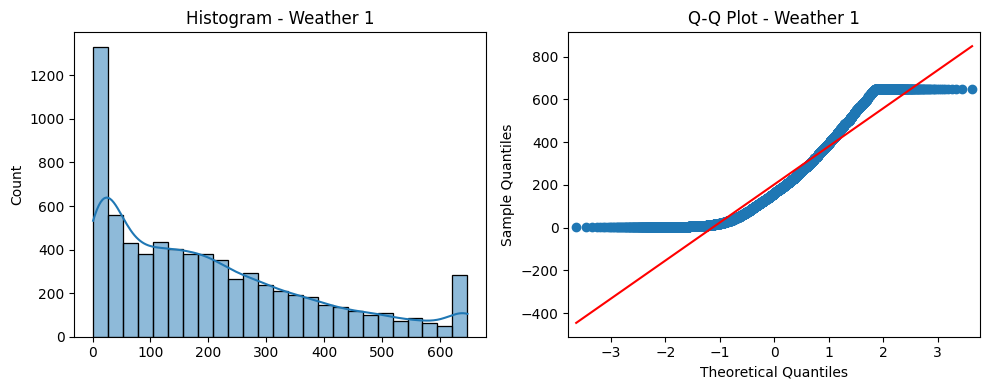

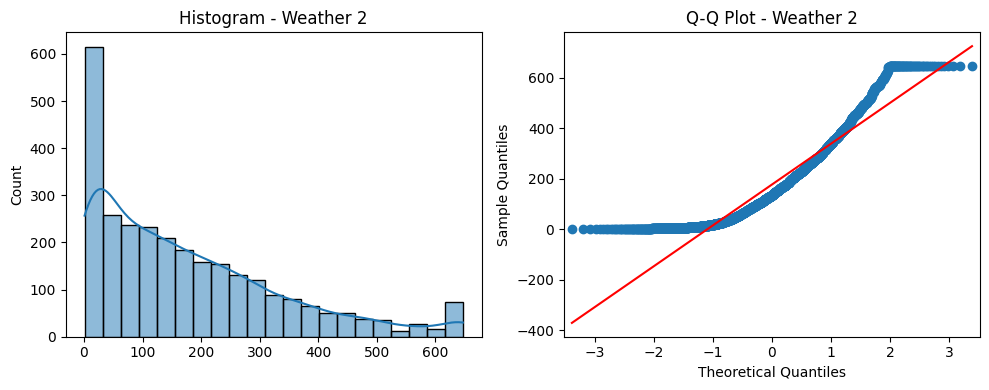

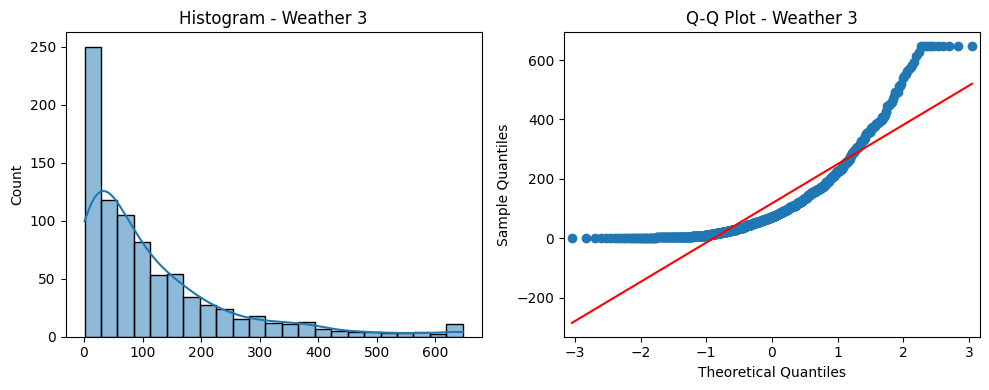

Skewness and Kurtosis per Weather Group:
Weather 1: Skewness = 0.89, Kurtosis = -0.08
Weather 2: Skewness = 1.09, Kurtosis = 0.59
Weather 3: Skewness = 1.86, Kurtosis = 3.61

Shapiro-Wilk Test Results:
Weather 1: W = 0.8988, p-value = 3.7238070008534003e-56
Weather 2: W = 0.8865, p-value = 1.7719335162413008e-41
Weather 3: W = 0.7887, p-value = 6.40167565957445e-32

Levene’s Test for Equal Variances: Statistic = 88.99190403222889, p-value = 4.612832391153636e-39

One-way ANOVA: F-statistic = 102.6070209331648, p-value = 7.133500452476198e-45


In [99]:
# Convert datetime and weather columns
df_yulu['datetime'] = pd.to_datetime(df_yulu['datetime'])
df_yulu['weather'] = df_yulu['weather'].astype('category')
df_yulu['count'] = df_yulu['count'].astype(int)

# Group data by weather condition
weather_groups_raw = {name: group['count'].values for name, group in df_yulu.groupby('weather')}

# Filter out groups with fewer than 3 observations
weather_groups = {k: v for k, v in weather_groups_raw.items() if len(v) >= 3}

# --- Normality Check ---
# Histogram and Q-Q Plot for each weather group
for name, group in weather_groups.items():
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    sns.histplot(group, kde=True)
    plt.title(f'Histogram - Weather {name}')
    
    plt.subplot(1, 2, 2)
    qqplot(group, line='s', ax=plt.gca())
    plt.title(f'Q-Q Plot - Weather {name}')
    plt.tight_layout()
    plt.show()

# Skewness and Kurtosis
skew_kurtosis = [(name, skew(group), kurtosis(group)) for name, group in weather_groups.items()]

# Shapiro-Wilk Test
shapiro_results = [(name, *shapiro(group)) for name, group in weather_groups.items()]

# --- Homogeneity of Variance ---
levene_stat, levene_p = levene(*weather_groups.values())

# --- One-way ANOVA ---
anova_stat, anova_p = f_oneway(*weather_groups.values())

# Display results
print("Skewness and Kurtosis per Weather Group:")
for name, s, k in skew_kurtosis:
    print(f"Weather {name}: Skewness = {s:.2f}, Kurtosis = {k:.2f}")

print("\nShapiro-Wilk Test Results:")
for name, stat, p in shapiro_results:
    print(f"Weather {name}: W = {stat:.4f}, p-value = {p}")

print(f"\nLevene’s Test for Equal Variances: Statistic = {levene_stat}, p-value = {levene_p}")
print(f"\nOne-way ANOVA: F-statistic = {anova_stat}, p-value = {anova_p}")



## Decision ##
Since p-value < 0.05, we reject the null hypothesis.

## Conclusion & Recommendations ##
**Conclusion:**
There is a statistically significant difference in bike rental demand across different weather conditions.

**Recommendations:**
- Weather 1 (Clear/Few Clouds) has the highest demand — ensure maximum bike availability.
- Weather 3 (Snow/Heavy Rain) shows lowest demand — consider reducing fleet or offering incentives.
- Use this insight for dynamic fleet management, pricing strategies, and maintenance scheduling.

## Check if the Weather conditions are significantly different during different Seasons? ##
- Null Hypothesis (H₀): Weather conditions are independent of seasons (i.e., no significant difference).
- Alternative Hypothesis (H₁): Weather conditions are dependent on seasons (i.e., there is a significant difference).
- alpha=5%

In [100]:
# Create a contingency table between 'weather' and 'season'
contingency_table = pd.crosstab(df_yulu['weather'], df['season'])
print(contingency_table)
# Perform the Chi-square test
chi2_stat, p_val, dof, expected = chi2_contingency(contingency_table)

# Set significance level
alpha = 0.05

# Print results
print("Chi-square Statistic:", chi2_stat)
print("Degrees of Freedom:", dof)
print("P-value:", p_val)

# Decision
if p_val <= alpha:
    print("Reject the null hypothesis: Weather conditions are significantly different across seasons.")
else:
    print("Fail to reject the null hypothesis: No significant difference in weather conditions across seasons.")



season      1     2     3     4
weather                        
1        1759  1801  1930  1702
2         715   708   604   807
3         211   224   199   225
4           1     0     0     0
Chi-square Statistic: 49.15865559689363
Degrees of Freedom: 9
P-value: 1.5499250736864862e-07
Reject the null hypothesis: Weather conditions are significantly different across seasons.


## Conclusion & Recommendations ##
**Conclusion:**
There is a statistically significant relationship between weather conditions and seasons.

**Recommendations:**
- Seasonal planning is essential. For example:
    - Winter may have more adverse weather (e.g., snow, fog), requiring reduced fleet or weather-proofing.
    - Summer and Spring may see more favorable weather, suggesting higher demand and increased availability.
- Use this insight for seasonal marketing, maintenance scheduling, and inventory management.

# Strategic Insights #
**1. Weather & Season Impact Demand**
- Clear weather (Weather 1) sees the highest demand.
- Adverse weather (Weather 3) significantly reduces rentals.
- Weather patterns vary significantly across seasons, indicating seasonal planning is essential.
  
**2. Weekday vs Weekend Demand**
- No statistically significant difference in demand between weekdays and weekends.
- Suggests consistent usage patterns, likely a mix of commuting and leisure.
  
**3. Demand Drivers**
- Temperature positively influences demand.
- Humidity and poor weather negatively impact rentals.
- Registered users are the primary contributors to total demand.
  
**4. User Segments**
- Casual users show moderate correlation with demand.
- Registered users are highly correlated with total rentals, indicating loyalty and repeat usage.

# Recommendations for Profitability #
**1. Dynamic Fleet Management**
- Scale up fleet during clear weather and peak seasons (spring/summer).
- Reduce fleet or reallocate during low-demand periods (e.g., rainy or winter days).
  
**2. Weather-Based Pricing & Incentives**
- Introduce dynamic pricing: discounts during poor weather to stimulate demand.
- Offer loyalty rewards or free ride minutes for registered users during off-peak times.
  
**3. Operational Efficiency**
- Use predictive analytics to forecast demand based on weather and season.
- Optimize maintenance schedules during low-demand periods.
  
**4. Marketing & Engagement**
- Target casual users with conversion campaigns to become registered users.
- Promote weekend leisure rides with family/group discounts or gamified challenges.
  
**5. Infrastructure & Partnerships**
- Collaborate with local governments for dedicated bike lanes and parking zones.
- Partner with corporates and campuses to offer subscription-based commuting plans.